# Plotting a graph over time of the affilitions

In [1]:
import pandas as pd
import numpy as np
melted_master_condenced = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/QJE_Melted_Weights_applied.xlsx') 
print(melted_master_condenced.shape)
melted_master_condenced = melted_master_condenced[['Article_ID','Weight','Affiliation','year']]
melted_master_condenced = melted_master_condenced.reset_index(drop=True)
melted_master_condenced.head()

(2890, 74)


KeyError: "['Weight', 'Affiliation', 'year'] not in index"

In [2]:
melted_master_condenced['decade'] = ''
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1940) & (melted_master_condenced['year'] < 1950), 1940, melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1950) & (melted_master_condenced['year'] < 1960), 1950, melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1960) & (melted_master_condenced['year'] < 1970), 1960, melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1970) & (melted_master_condenced['year'] < 1980), 1970, melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1980) & (melted_master_condenced['year'] < 1990), 1980, melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1990) & (melted_master_condenced['year'] < 2000), 1990, melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 2000) & (melted_master_condenced['year'] < 2011), 2000, melted_master_condenced['decade'])
print(melted_master_condenced.head())
print(melted_master_condenced.tail())

   Article_ID  Weight              Affiliation  year decade
0     1825913     1.0     Washington Dc (City)  1940   1940
1     1825908     1.0    University Of Chicago  1940   1940
2     1824384     1.0      Columbia University  1940   1940
3     1824382     1.0       Cornell University  1940   1940
4     1824381     1.0  University Of Edinburgh  1940   1940
      Article_ID    Weight                          Affiliation  year decade
6299      653137  0.166667                University Of Bristol  2010   2000
6300      650305  0.500000                University Of Toronto  2010   2000
6301      652462  1.000000                University Of Chicago  2010   2000
6302      657949  0.333333  Federal Reserve Bank Of Minneapolis  2010   2000
6303      651513  0.500000                Georgetown University  2010   2000


# Ranking the Universities based on their number of papers per published per decade

In [3]:
#Gets the top 10 overall
melted_master_condenced = melted_master_condenced.sort_values(by=['year'])
melted_master_condenced['aff_cum_sum'] = melted_master_condenced.groupby(['Affiliation'])['Weight'].cumsum()

mask_journal = melted_master_condenced['Affiliation'].isin(['National Bureau Of Economic Research'])
melted_master_condenced = melted_master_condenced[~mask_journal]

highest_vals = melted_master_condenced.drop_duplicates(subset = ['Affiliation'], keep = 'last')
highest_vals_10 = highest_vals.nlargest(10,'aff_cum_sum')
print(highest_vals_10.shape)
#print(highest_vals_10.head())
print(highest_vals_10.iat[6,2])

melted_master_condenced_decade = melted_master_condenced[['Article_ID','Weight','Affiliation','decade']]

a = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[6,2]]
a['aff_cum_counts_yearly'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
a = a.drop_duplicates(subset = ['decade'], keep = 'last')
print(a.head())
print(a.shape)

(10, 6)
University Of Pennsylvania
      Article_ID    Weight                 Affiliation decade  \
89       1825228  0.333333  University Of Pennsylvania   1940   
706      1825393  1.000000  University Of Pennsylvania   1950   
1375     1830033  0.500000  University Of Pennsylvania   1960   
2749     1833329  0.500000  University Of Pennsylvania   1970   
3756     1831319  0.333333  University Of Pennsylvania   1980   

      aff_cum_counts_yearly  
89                 1.000000  
706                3.000000  
1375               8.000000  
2749              13.583333  
3756              18.750000  
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_20372/3928576346.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['aff_cum_counts_yearly'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()


In [4]:
a = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[0,2]]
a['aff_cum_sum_decade'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
a = a.drop_duplicates(subset = ['decade'], keep = 'last')
print(a.shape)

b = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[1,2]]
b['aff_cum_sum_decade'] = b.groupby(['Affiliation','decade'])['Weight'].cumsum()
b = b.drop_duplicates(subset = ['decade'], keep = 'last')
print(b.shape)

c = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[2,2]]
c['aff_cum_sum_decade'] = c.groupby(['Affiliation','decade'])['Weight'].cumsum()
c = c.drop_duplicates(subset = ['decade'], keep = 'last')
print(c.shape)

d = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[3,2]]
d['aff_cum_sum_decade'] = d.groupby(['Affiliation','decade'])['Weight'].cumsum()
d = d.drop_duplicates(subset = ['decade'], keep = 'last')
print(d.shape)

e = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[4,2]]
e['aff_cum_sum_decade'] = e.groupby(['Affiliation','decade'])['Weight'].cumsum()
e = e.drop_duplicates(subset = ['decade'], keep = 'last')
print(e.shape)

f = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[5,2]]
f['aff_cum_sum_decade'] = f.groupby(['Affiliation','decade'])['Weight'].cumsum()
f = f.drop_duplicates(subset = ['decade'], keep = 'last')
print(f.shape)

g = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[6,2]]
g['aff_cum_sum_decade'] = g.groupby(['Affiliation','decade'])['Weight'].cumsum()
g = g.drop_duplicates(subset = ['decade'], keep = 'last')
print(g.shape)

h = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[7,2]]
h['aff_cum_sum_decade'] = h.groupby(['Affiliation','decade'])['Weight'].cumsum()
h = h.drop_duplicates(subset = ['decade'], keep = 'last')
print(h.shape)

i = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[8,2]]
i['aff_cum_sum_decade'] = i.groupby(['Affiliation','decade'])['Weight'].cumsum()
i = i.drop_duplicates(subset = ['decade'], keep = 'last')
print(i.shape)

j = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[9,2]]
j['aff_cum_sum_decade'] = j.groupby(['Affiliation','decade'])['Weight'].cumsum()
j = j.drop_duplicates(subset = ['decade'], keep = 'last')
print(j.shape)

/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_20372/1058402594.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['aff_cum_sum_decade'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_20372/1058402594.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b['aff_cum_sum_decade'] = b.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_20372/1058402594.py:12: SettingWith

(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_20372/1058402594.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  h['aff_cum_sum_decade'] = h.groupby(['Affiliation','decade'])['Weight'].cumsum()


(7, 5)
(7, 5)
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_20372/1058402594.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  i['aff_cum_sum_decade'] = i.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_20372/1058402594.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  j['aff_cum_sum_decade'] = j.groupby(['Affiliation','decade'])['Weight'].cumsum()


In [5]:
ranked = pd.concat([a,b,c,d,e,f,g,h,i,j], axis=0)
ranked = ranked.sort_values(by=['decade','Affiliation'])
print(ranked.shape)

ranked['Rank'] = ranked.groupby(['decade'])['aff_cum_sum_decade'].rank(method = 'max', ascending= False)
print(ranked.shape)
print(ranked.tail(20))
#ranked.to_excel('/Users/MattJohnson/Desktop/Affiliations/2_Extracting affilitations/2_Fuzzy matching/Combined journals/Combined journal yearly rank.xlsx') 

(70, 5)
(70, 6)
      Article_ID    Weight                            Affiliation decade  \
4918      250061  0.250000                    Columbia University   1990   
4858      250104  0.500000                     Harvard University   1990   
4906      250084  0.500000  Massachusetts Institute Of Technology   1990   
4792      250014  1.000000                Northwestern University   1990   
4900      250084  0.500000                   Princeton University   1990   
4862      250105  1.000000                    Stanford University   1990   
4865      250092  1.000000  University Of California, Los Angeles   1990   
4864      250112  0.500000                  University Of Chicago   1990   
4856      250102  1.000000             University Of Pennsylvania   1990   
4859      250106  1.000000                        Yale University   1990   
6216      655858  0.250000                    Columbia University   2000   
6226      653714  0.333333                     Harvard University   2000

In [6]:
#ranked.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.3/JPE_Ranked_data.xlsx') 

In [25]:
ranked = ranked.rename(columns={"decade": "Decade"})

In [26]:
pivot = ranked.pivot(index='Decade', columns='Affiliation', values='Rank')
pivot

/usr/local/lib/python3.9/site-packages/pandas/core/algorithms.py:794: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  uniques = Index(uniques)


Affiliation,Columbia University,Harvard University,Massachusetts Institute Of Technology,Northwestern University,Princeton University,Stanford University,"University Of California, Los Angeles",University Of Chicago,University Of Pennsylvania,Yale University
Decade,,,,,,,,,,
1940,4.0,4.0,5.0,7.0,2.0,6.0,10.0,1.0,10.0,10.0
1950,4.0,8.0,2.0,6.0,9.0,3.0,7.0,1.0,10.0,6.0
1960,5.0,9.0,2.0,4.0,6.0,7.0,8.0,1.0,10.0,3.0
1970,3.0,2.0,6.0,10.0,5.0,8.0,4.0,1.0,9.0,7.0
1980,9.0,4.0,2.0,8.0,6.0,4.0,10.0,1.0,5.0,7.0
1990,10.0,3.0,2.0,7.0,6.0,5.0,8.0,1.0,4.0,9.0
2000,8.0,3.0,2.0,5.0,6.0,7.0,9.0,1.0,4.0,10.0


In [27]:
pivot_ordered = pivot[['University Of Chicago','Massachusetts Institute Of Technology','Harvard University','University Of Pennsylvania','Northwestern University','Princeton University','Stanford University','Columbia University', 'University Of California, Los Angeles','Yale University']]
pivot_ordered

Affiliation,University Of Chicago,Massachusetts Institute Of Technology,Harvard University,University Of Pennsylvania,Northwestern University,Princeton University,Stanford University,Columbia University,"University Of California, Los Angeles",Yale University
Decade,,,,,,,,,,
1940,1.0,5.0,4.0,10.0,7.0,2.0,6.0,4.0,10.0,10.0
1950,1.0,2.0,8.0,10.0,6.0,9.0,3.0,4.0,7.0,6.0
1960,1.0,2.0,9.0,10.0,4.0,6.0,7.0,5.0,8.0,3.0
1970,1.0,6.0,2.0,9.0,10.0,5.0,8.0,3.0,4.0,7.0
1980,1.0,2.0,4.0,5.0,8.0,6.0,4.0,9.0,10.0,7.0
1990,1.0,2.0,3.0,4.0,7.0,6.0,5.0,10.0,8.0,9.0
2000,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0


In [32]:
ranked['aff_cum_sum_decade'] = ranked['aff_cum_sum_decade'].apply(lambda x: round(x, 1))
pivot2 = ranked.pivot(index='Decade', columns='Affiliation', values='aff_cum_sum_decade')
pivot2_ordered = pivot2[['University Of Chicago','Massachusetts Institute Of Technology','Harvard University','University Of Pennsylvania','Northwestern University','Princeton University','Stanford University','Columbia University', 'University Of California, Los Angeles','Yale University']]

pivot2_ordered

Affiliation,University Of Chicago,Massachusetts Institute Of Technology,Harvard University,University Of Pennsylvania,Northwestern University,Princeton University,Stanford University,Columbia University,"University Of California, Los Angeles",Yale University
Decade,,,,,,,,,,
1940,46.0,6.0,10.0,1.0,3.0,11.0,5.0,10.0,1.0,1.0
1950,44.5,16.0,6.0,3.0,8.0,5.0,12.5,11.0,7.5,8.0
1960,60.1,19.9,8.3,8.0,12.5,11.5,10.2,11.8,9.0,19.8
1970,64.8,21.0,34.5,13.6,7.9,21.5,17.8,23.7,21.8,19.0
1980,39.2,24.6,20.2,18.8,13.8,17.1,20.2,11.2,10.1,14.7
1990,42.0,20.1,19.6,17.4,11.9,13.0,16.8,3.8,9.8,4.0
2000,37.7,16.1,15.4,12.8,12.3,12.2,11.3,9.2,8.9,6.5


In [42]:
invert_pivot = ranked.pivot(index='Affiliation', columns='Decade', values='aff_cum_sum_decade')
invert_pivot
invert_pivot.sort_values(by=2000, ascending=False)

Decade,1940,1950,1960,1970,1980,1990,2000
Affiliation,,,,,,,
University Of Chicago,46.0,44.5,60.1,64.8,39.2,42.0,37.7
Massachusetts Institute Of Technology,6.0,16.0,19.9,21.0,24.6,20.1,16.1
Harvard University,10.0,6.0,8.3,34.5,20.2,19.6,15.4
University Of Pennsylvania,1.0,3.0,8.0,13.6,18.8,17.4,12.8
Northwestern University,3.0,8.0,12.5,7.9,13.8,11.9,12.3
Princeton University,11.0,5.0,11.5,21.5,17.1,13.0,12.2
Stanford University,5.0,12.5,10.2,17.8,20.2,16.8,11.3
Columbia University,10.0,11.0,11.8,23.7,11.2,3.8,9.2
"University Of California, Los Angeles",1.0,7.5,9.0,21.8,10.1,9.8,8.9


<Figure size 432x288 with 0 Axes>

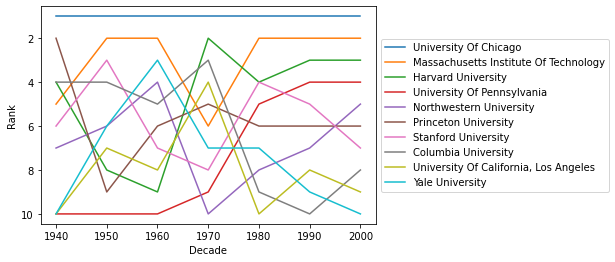

In [29]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = pivot_ordered.plot(xticks=pivot.index, ylabel='Rank')
leg = plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.invert_yaxis()
plt.show()